In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state = 2021
                                                   )

model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE =', mean_absolute_error(y_test, y_predicted))
print('RMSE =', mean_squared_error(y_test, y_predicted))

Train r2 = 0.8583088141424131
Test r2 = 0.8606236418703774
MAE = 878.6653456931837
RMSE = 2170006.4781936174


In [4]:
def cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2'):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f"Scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Std: {scores.std()}")

In [5]:
cross_val_results(X, y, model)

Scores: [0.85810488 0.85990252 0.86106744 0.85929087 0.85445913 0.84970439
 0.85640823 0.86147999 0.86109155 0.86470322]
Mean: 0.8586212229892711
Std: 0.004016674694967562


### Select the features with Ridge, Lasso and ElasticNet models

#### Regularisators

Linear Regression is the most basic method from the regression family, where the model is not penalised for its choice of weights at all. However, this means that during the training process, if the model considers a particular feature important, it will assign a large weight to that feature. This can sometimes cause overfitting in smaller datasets.

Lasso, Ridge, and ElasticNet are methods from the linear regression family that penalize the model for its weights. They reduce model complexity and prevent over-fitting.

#### Ridge

In Ridge regression, the cost function is altered by adding a penalty equivalent to the square of the magnitude of the coefficients.

The penalty term lambda('alpha’ = 1.0(default) in Scikit Learn) regularises the coefficients such that if the coefficients take large values, the optimisation function is penalised.

The higher the alpha is, the bigger the penalty term, and therefore, the magnitude of the coefficients is reduced.

Therefore, Ridge regression shrinks the coefficients, which helps reduce model complexity and mitigate multicollinearity.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

In [6]:
from sklearn.linear_model import Ridge

In [7]:
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state = 2021
                                                   )

In [8]:
# in scikit-learn lambda is specified as alpha, and by default it is eqaul to 1. 
# Larger values specify stronger regularization.

ridge_regr_model = Ridge(alpha=1)

ridge_regr_model.fit(X_train, y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [9]:
ridge_regr_model.coef_

array([10528.20743788,  -213.81483446,  -105.14815225, -1476.08751198,
         279.9279325 ,    75.88011444])

In [10]:
ridge_regr_model.score(X_train, y_train)

0.8583083147536604

In [11]:
ridge_regr_model.score(X_test, y_test)

0.8606171362517476

In [12]:
cross_val_results(X, y, model=Ridge(alpha=1))

Scores: [0.85810432 0.85990083 0.86104699 0.85928505 0.8544549  0.84975996
 0.85644554 0.86146543 0.86109999 0.86469047]
Mean: 0.8586253478406907
Std: 0.003998911151147186


#### Lasso

Lasso is a modified linear regression method where the model is penalised for the sum of the absolute values of the weights. The absolute value of weight tends to be reduced. Some of them may be reduced to zeros. So, the only difference between Ridge and Lasso is that instead of taking the square of the coefficients, magnitudes are taken into account.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

In [13]:
from sklearn.linear_model import Lasso

In [14]:
lasso_regr_model = Lasso(alpha=1)

lasso_regr_model.fit(X_train, y_train)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [15]:
lasso_regr_model.coef_

array([10428.72459713,  -207.17710929,  -105.10116029, -1314.75039422,
         206.1914325 ,    -0.        ])

In [16]:
lasso_regr_model.score(X_train, y_train)

0.8582845806625883

In [17]:
lasso_regr_model.score(X_test, y_test)

0.8609772367796544

In [18]:
cross_val_results(X, y, model=Lasso(alpha=1))

Scores: [0.85807164 0.85985284 0.86091432 0.85922435 0.85438366 0.85022092
 0.85852466 0.86135872 0.86115086 0.86458975]
Mean: 0.8588291718066365
Std: 0.0038086251145011065


#### ElasticNet

ElasticNet is a hybrid of Lasso and Ridge, where both absolute value penalisation and squared penalisation are included, regulated by the L1_ratio coefficient. The L1_ratio takes values between 0 and 1. 

* L1_ratio = 0 is the Lasso penalty.
* L1_ratio = 1 is the Ridge penalty. 

L1_ratio between 0 and 1 is a combination of the Ridge and Lasso penalty. 

For Alpha = 0, it is equivalent to Linear Regression.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

In [19]:
from sklearn.linear_model import ElasticNet

In [20]:
elastic_regr_model = ElasticNet(alpha=1, l1_ratio = 0.5)

elastic_regr_model.fit(X_train, y_train)

# alpha - penalty term

,alpha,1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [21]:
elastic_regr_model.coef_

array([ 650.97349784,  -36.17013284,  -33.16823051, 1060.04663706,
       1029.06422904,  641.02159189])

In [22]:
elastic_regr_model.score(X_train, y_train)

0.7764777858438838

In [23]:
elastic_regr_model.score(X_test, y_test)

0.7732086661426145

In [24]:
cross_val_results(X, y, model=ElasticNet(alpha=1, l1_ratio = 0.5))

Scores: [0.78351666 0.77830612 0.76570412 0.77730295 0.77729043 0.77355286
 0.73576616 0.7789764  0.78708257 0.78250002]
Mean: 0.7739998298397184
Std: 0.01389194813419798


The regularisation helps us reduce multicollinearity by decreasing the magnitude of the coefficients. This way, the coefficients that harm the model will have a reduced influence on the target.

The benefit of regularisation over the VIF is that it automatically determines which coefficients harm the model and penalises them, but does not remove them all from the model. Thus, the score will not be significantly affected.

#### Task 1: Train a linear regression model using the Ridge, Lasso, and ElasticNet models.

Validate the created models and explain the results.

Environment Setup and Imports

In [25]:
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

Data Loading and Initial Inspection

In [26]:
df = sns.load_dataset("mpg")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [27]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Data Cleaning and Preparation

In [28]:
# horsepower has missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [29]:
# 'name' is text-heavy and not useful for regression
df = df.drop(columns=['name'])

In [30]:
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

Feature and Target Separation

In [31]:
X = df.drop(columns=['mpg'])  # target
y = df['mpg']

Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Ridge Regression

In [44]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [45]:
y_pred_ridge = ridge.predict(X_test_scaled)

In [46]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 2.8876330763169515
Ridge R2: 0.8449139611648632


Cross-Validation

In [47]:
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=10)

print("Ridge CV Mean:", ridge_cv.mean())
print("Ridge CV Std:", ridge_cv.std())

Ridge CV Mean: 0.8017051953822145
Ridge CV Std: 0.03014118626447599


In [48]:
ridge_coeffs = pd.Series(ridge.coef_, index=X.columns)
ridge_coeffs

cylinders      -0.232724
displacement    1.762959
horsepower     -0.581348
weight         -5.690681
acceleration    0.143323
model_year      2.942423
origin_japan   -0.090877
origin_usa     -1.394117
dtype: float64

Lasso Regression

In [49]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [50]:
y_pred_lasso = lasso.predict(X_test_scaled)

In [51]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 2.9145038378820227
Lasso R2: 0.8420142373461508


In [52]:
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=10)

print("Lasso CV Mean:", lasso_cv.mean())
print("Lasso CV Std:", lasso_cv.std())

Lasso CV Mean: 0.8023630760203769
Lasso CV Std: 0.031196251145388713


In [53]:
lasso_coeffs = pd.Series(lasso.coef_, index=X.columns)
lasso_coeffs

cylinders       0.000000
displacement    0.000000
horsepower     -0.182858
weight         -4.821977
acceleration    0.000000
model_year      2.792838
origin_japan    0.000000
origin_usa     -0.991018
dtype: float64

ElasticNet

In [54]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [55]:
y_pred_elastic = elastic.predict(X_test_scaled)

In [56]:
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print("ElasticNet RMSE:", rmse_elastic)
print("ElasticNet R2:", r2_elastic)

ElasticNet RMSE: 2.8901578502023564
ElasticNet R2: 0.8446426466677684


In [59]:
elastic_cv = cross_val_score(elastic, X_train_scaled, y_train, cv=10)

print("ElasticNet CV Mean:", elastic_cv.mean())
print("ElasticNet CV Std:", elastic_cv.std())

ElasticNet CV Mean: 0.7975949626501149
ElasticNet CV Std: 0.02833597577317457


In [60]:
elastic_coeffs = pd.Series(elastic.coef_, index=X.columns)
elastic_coeffs

cylinders      -0.188110
displacement   -0.000000
horsepower     -0.772624
weight         -3.969361
acceleration   -0.010506
model_year      2.628801
origin_japan    0.081413
origin_usa     -1.077464
dtype: float64

Model Comparison Summary

In [61]:
comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "RMSE": [rmse_ridge, rmse_lasso, rmse_elastic],
    "R2": [r2_ridge, r2_lasso, r2_elastic],
    "CV Mean": [ridge_cv.mean(), lasso_cv.mean(), elastic_cv.mean()],
    "CV Std": [ridge_cv.std(), lasso_cv.std(), elastic_cv.std()]
})

comparison

,Model,RMSE,R2,CV Mean,CV Std
0,Ridge,2.887633,0.844914,0.801705,0.030141
1,Lasso,2.914504,0.842014,0.802363,0.031196
2,ElasticNet,2.890158,0.844643,0.797595,0.028336


In [62]:
coeff_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

coeff_comparison

,Feature,Ridge,Lasso,ElasticNet
0,cylinders,-0.232724,0.000000,-0.188110
1,displacement,1.762959,0.000000,-0.000000
2,horsepower,-0.581348,-0.182858,-0.772624
3,weight,-5.690681,-4.821977,-3.969361
4,acceleration,0.143323,0.000000,-0.010506
5,model_year,2.942423,2.792838,2.628801
6,origin_japan,-0.090877,0.000000,0.081413
7,origin_usa,-1.394117,-0.991018,-1.077464


In [63]:
def evaluate_model(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.2f}")
    print("-" * 30)

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge", y_test, y_pred_ridge)
evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("ElasticNet", y_test, y_pred_elastic)

Linear Regression
RMSE: 2.89
R2: 0.84
------------------------------
Ridge
RMSE: 2.89
R2: 0.84
------------------------------
Lasso
RMSE: 2.91
R2: 0.84
------------------------------
ElasticNet
RMSE: 2.89
R2: 0.84
------------------------------


In [64]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

coeffs

,Feature,Linear,Ridge,Lasso,ElasticNet
0,cylinders,-0.278695,-0.232724,0.000000,-0.188110
1,displacement,2.033373,1.762959,0.000000,-0.000000
2,horsepower,-0.539182,-0.581348,-0.182858,-0.772624
3,weight,-5.914735,-5.690681,-4.821977,-3.969361
4,acceleration,0.187514,0.143323,0.000000,-0.010506
5,model_year,2.971431,2.942423,2.792838,2.628801
6,origin_japan,-0.111843,-0.090877,0.000000,0.081413
7,origin_usa,-1.433003,-1.394117,-0.991018,-1.077464


In [65]:
alphas = [0.01, 0.1, 1, 10]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    
    print(f"Alpha: {a}, RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}")

Alpha: 0.01, RMSE: 2.89
Alpha: 0.1, RMSE: 2.89
Alpha: 1, RMSE: 2.89
Alpha: 10, RMSE: 2.90


In [66]:
from sklearn.model_selection import cross_val_score

def cross_val_results(model, X, y):
    scores = cross_val_score(model, X, y, cv=10)
    print(f"Scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Std: {scores.std()}")

cross_val_results(ridge, X_train_scaled, y_train)
cross_val_results(lasso, X_train_scaled, y_train)
cross_val_results(elastic, X_train_scaled, y_train)

Scores: [0.85483738 0.8123474  0.76570724 0.79372963 0.84868808 0.79933347
 0.80811741 0.78160837 0.75579261 0.79689037]
Mean: 0.8017051953822145
Std: 0.03014118626447599
Scores: [0.84759121 0.81664159 0.75792194 0.78936132 0.86362239 0.79777781
 0.80131296 0.77304885 0.77589099 0.8004617 ]
Mean: 0.8023630760203769
Std: 0.031196251145388713
Scores: [0.83603864 0.81291509 0.7501893  0.7913361  0.850255   0.80192094
 0.79595616 0.76742209 0.78667902 0.78323729]
Mean: 0.7975949626501149
Std: 0.02833597577317457


In [67]:
alphas = [0.01, 0.1, 1, 10]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"Alpha {a}: RMSE {np.sqrt(mean_squared_error(y_test, pred)):.2f}")

Alpha 0.01: RMSE 2.89
Alpha 0.1: RMSE 2.89
Alpha 1: RMSE 2.89
Alpha 10: RMSE 2.90


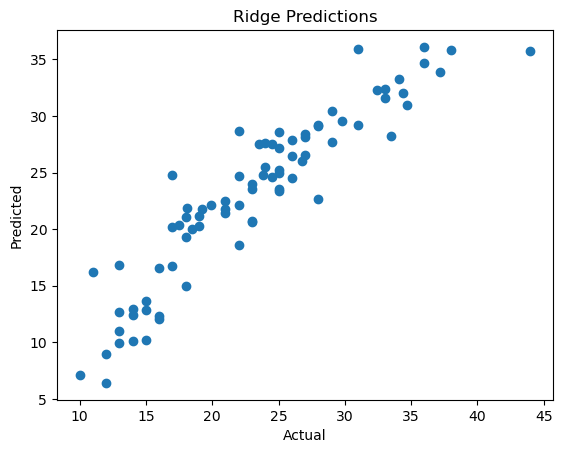

In [68]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Predictions")
plt.show()

### Model Performance Summary

The three regularised regression models (Ridge, Lasso, and ElasticNet) were evaluated using both holdout test metrics and cross-validation.

All models produced very similar performance:
- RMSE values are closely aligned (≈ 2.89–2.91)
- R² values are consistent at approximately 0.84
- Cross-validation mean scores are also highly comparable (~0.80)
- Standard deviation across folds is low (~0.03), indicating stable model behaviour

This indicates that:
- Regularisation does not materially improve predictive performance over standard linear regression for this dataset
- The dataset does not exhibit strong overfitting or instability that requires aggressive penalisation
- Feature relationships are relatively stable, with no extreme coefficient inflation

Differences between models:
- **Ridge** slightly outperforms others in RMSE and R², suggesting mild benefit from coefficient shrinkage
- **Lasso** performs marginally worse, which may indicate that forcing coefficients to zero removes some useful information
- **ElasticNet** behaves similarly to Ridge, suggesting the dataset benefits more from L2 regularisation than L1

Overall, the results suggest that:
- The problem is well-conditioned
- Regularisation provides **stability rather than performance gains**
- Model selection in this case may prioritise interpretability (Lasso) or robustness (Ridge) rather than accuracy improvements